pdg=-11 counts: [0, 0, 0]
pdg=11 counts: [12933, 10194, 25341]
pdg=22 counts: [50167, 46064, 32622]
pdg=0 counts: [0, 0, 49833]


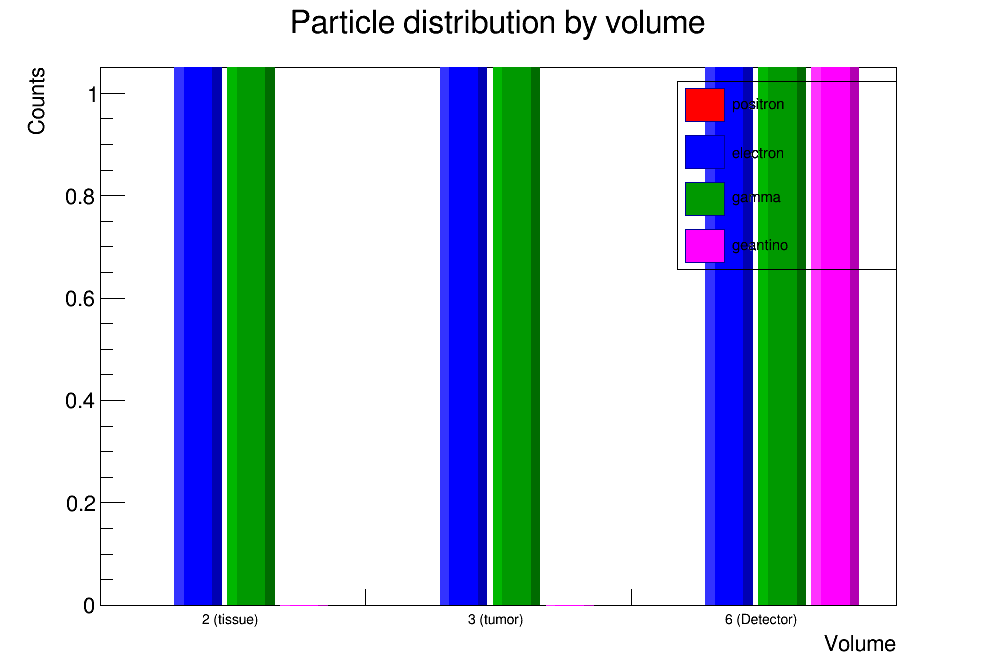

Warning in <TCanvas::Constructor>: Deleting canvas with same name: c
Info in <TCanvas::Print>: png file pdg_vs_vlm_bar.png has been created


In [3]:
import ROOT
from IPython.display import Image, display

%jsroot on

f = ROOT.TFile.Open("tumor.root")
t = f.Get("t")

c = ROOT.TCanvas("c", "PDG vs volume", 1000, 700)
c.cd()

legend = ROOT.TLegend(0.68, 0.60, 0.90, 0.88)
legend.SetBorderSize(1)
legend.SetFillStyle(0)
legend.SetTextSize(0.025)

colors = [ROOT.kRed, ROOT.kBlue, ROOT.kGreen+2, ROOT.kMagenta]

names = {
    2: "tissue",
    3: "tumor",
    6: "Detector",
}

selected_vlm = [2, 3, 6]

pdg_labels = {
    -11: "positron",
     11: "electron",
     22: "gamma",
      0: "geantino"
}

pdg_order = [-11, 11, 22, 0]

hist_list = []
first = True

for i, pdg in enumerate(pdg_order):
    hname = f"h_pdg_{pdg}"

    old = ROOT.gROOT.FindObject(hname)
    if old:
        old.Delete()

    h = ROOT.TH1F(
        hname,
        "Particle distribution by volume;Volume;Counts",
        len(selected_vlm), 0, len(selected_vlm)
    )

    for j, vlm in enumerate(selected_vlm):
        count = t.GetEntries(f"vlm=={vlm} && pdg=={pdg}")
        h.SetBinContent(j + 1, count)
        h.GetXaxis().SetBinLabel(j + 1, f"{vlm} ({names.get(vlm,'')})")

    print(f"pdg={pdg} counts:",
          [t.GetEntries(f"vlm=={vlm} && pdg=={pdg}") for vlm in selected_vlm])

    h.SetFillColor(colors[i])
    h.SetBarWidth(0.18)
    h.SetBarOffset(0.08 + i * 0.2)
    h.SetStats(0)

    if first:
        h.Draw("bar2")
        first = False
    else:
        h.Draw("bar2 same")

    legend.AddEntry(h, pdg_labels[pdg], "f")
    hist_list.append(h)

legend.Draw()
c.Modified()
c.Update()

c.SaveAs("pdg_vs_vlm_bar.png")
display(Image(filename="pdg_vs_vlm_bar.png"))